## **Quiz1: 彩色影像轉灰階影像**
**基礎** / 
- 選一張彩色影像，轉成灰階影像

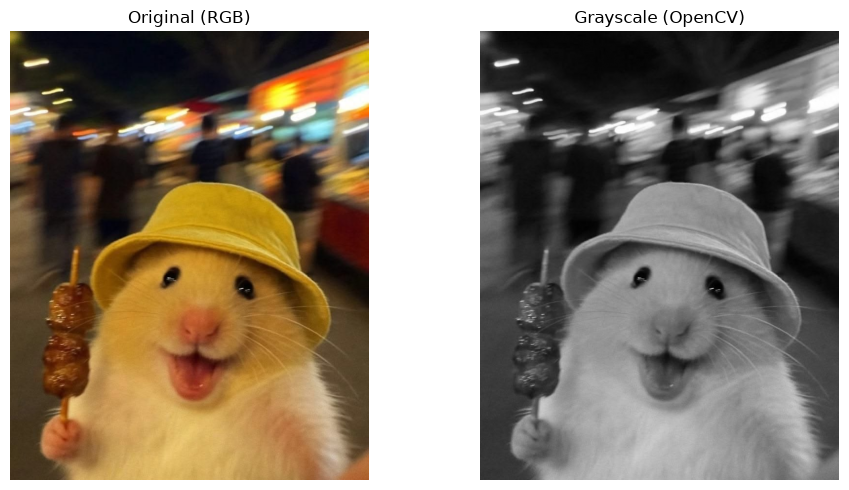

In [1]:
import cv2
from Code.plot_utils import plot_two_grids

img = cv2.imread('Data/q1.jpg')

# 色彩轉換
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)      # BGR 轉 RGB (Matplotlib 是以 RGB 顯示)
gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)    # BGR 轉灰階


plot_two_grids(img_rgb, gray_img, "Original (RGB)", "Grayscale (OpenCV)")

**進階** / 
- 使用 NumPy 自行實作灰階轉換演算法,並與 OpenCV 提供的方法
進行比較
- 建議重複執行 N 次並取平均值,比較(1)執行速度、(2)轉換結果、(3)兩種方法之間的差異

#### (1) 比較執行速度

In [2]:
import time
from Code.grayscale_np import bgr_to_gray_numpy

N = 100 # 執行次數

# OpenCV
start = time.perf_counter()
for _ in range(N):
    _ = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
cv_time = (time.perf_counter() - start) / N

# NumPy
start = time.perf_counter()
for _ in range(N):
    _ = bgr_to_gray_numpy(img)
np_time = (time.perf_counter() - start) / N

print(f"OpenCV time:平均執行時間 {cv_time*1000:.6f} ms")
print(f"NumPy time:平均執行時間 {np_time*1000:.6f} ms")

OpenCV time:平均執行時間 0.164328 ms
NumPy time:平均執行時間 10.700698 ms


#### (2)轉換結果

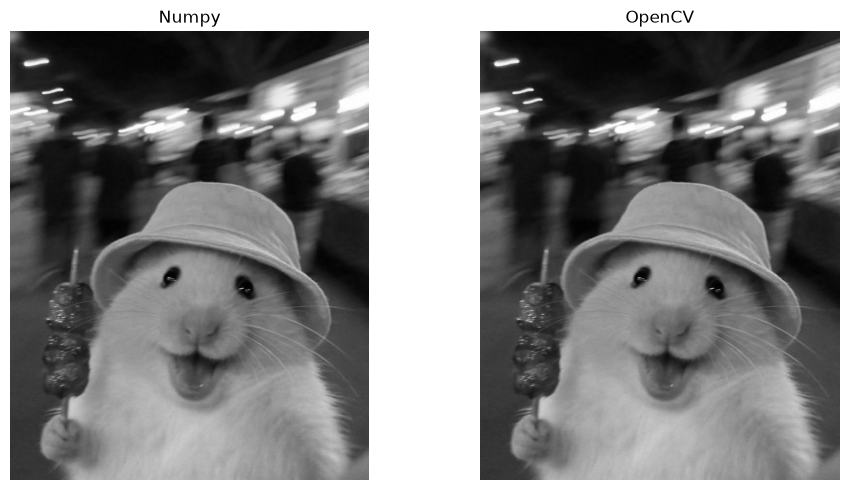

In [3]:
img = cv2.imread('Data/q1.jpg')

gray_numpy = bgr_to_gray_numpy(img)
gray_cv2 = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plot_two_grids(gray_numpy, gray_cv2, "Numpy", "OpenCV")

#### (3) 方法之間的差異

In [4]:
import numpy as np

# 1. 轉為 int 型態避免 uint8 溢位，並取絕對值
diff = np.abs(gray_cv2.astype(int) - gray_numpy.astype(int))

# 2. 計算量化統計指標
max_diff = np.max(diff)
mae = np.mean(diff)

print(f"最大像素差值: {max_diff}")
print(f"平均絕對誤差 (MAE): {mae:.6f}")

diff_count = np.count_nonzero(diff)
total_pixels = diff.size

print(f"\n相差非零的像素數量: {diff_count} / {total_pixels}")
print(f"差異比例: {(diff_count / total_pixels) * 100:.4f}%")
print(f"精確 MAE (科學記號): {mae:.6e}")

最大像素差值: 1
平均絕對誤差 (MAE): 0.000004

相差非零的像素數量: 3 / 677120
差異比例: 0.0004%
精確 MAE (科學記號): 4.430529e-06


## **Quiz2: Histogram Equalization**
**基礎** / 
- 選擇一張影像,用 Histogram Equalization 提升影像的明暗對比與動態範圍
- 繪製影像在 Histogram Equalization 處理前後的灰階 Histogram,觀察並比較亮度分布的差異

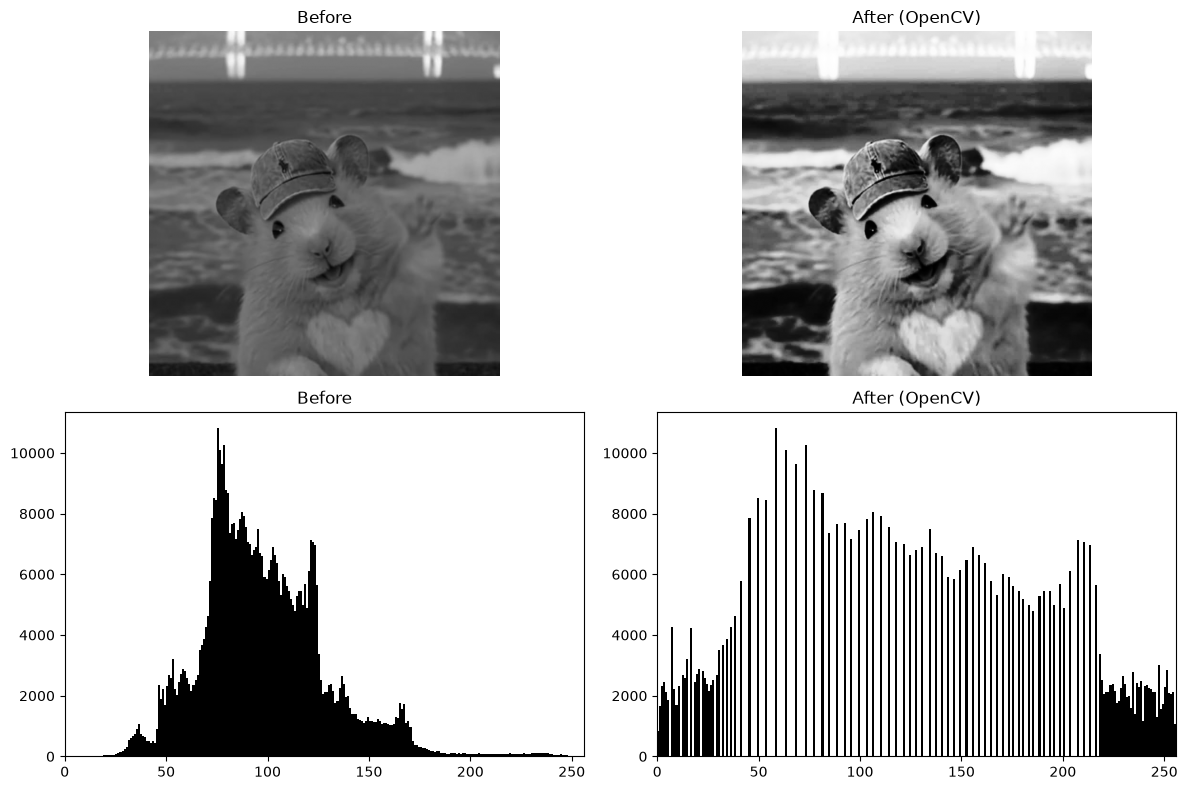

In [5]:
from Code.plot_utils import plot_image_and_hist_grid
img = cv2.imread('Data/q2.jpg', cv2.IMREAD_GRAYSCALE)

equ_cv = cv2.equalizeHist(img)

plot_image_and_hist_grid(img, equ_cv, title_before="Before", title_after="After (OpenCV)")



**進階** /
- 使用 NumPy 自行實作演算法,並與 OpenCV 提供的方法進行比較。
- 建議重複執行 N 次並取平均值,比較(1)執行速度、(2)影像增強效果、(3)兩種方法之間的差異

#### (1) 執行速度

In [6]:
from Code.histogram_np import equalize_hist_numpy

N = 100

# OpenCV
start = time.perf_counter()
for _ in range(N):
    _ = cv2.equalizeHist(img)
time_cv = (time.perf_counter() - start) / N

# NumPy
start = time.perf_counter()
for _ in range(N):
    _ = equalize_hist_numpy(img)
time_np = (time.perf_counter() - start) / N

print(f"OpenCV 平均執行時間: {time_cv * 1000:.4f} ms")
print(f"NumPy  平均執行時間: {time_np * 1000:.4f} ms")

OpenCV 平均執行時間: 0.9833 ms
NumPy  平均執行時間: 6.1218 ms


#### (2) 執行結果

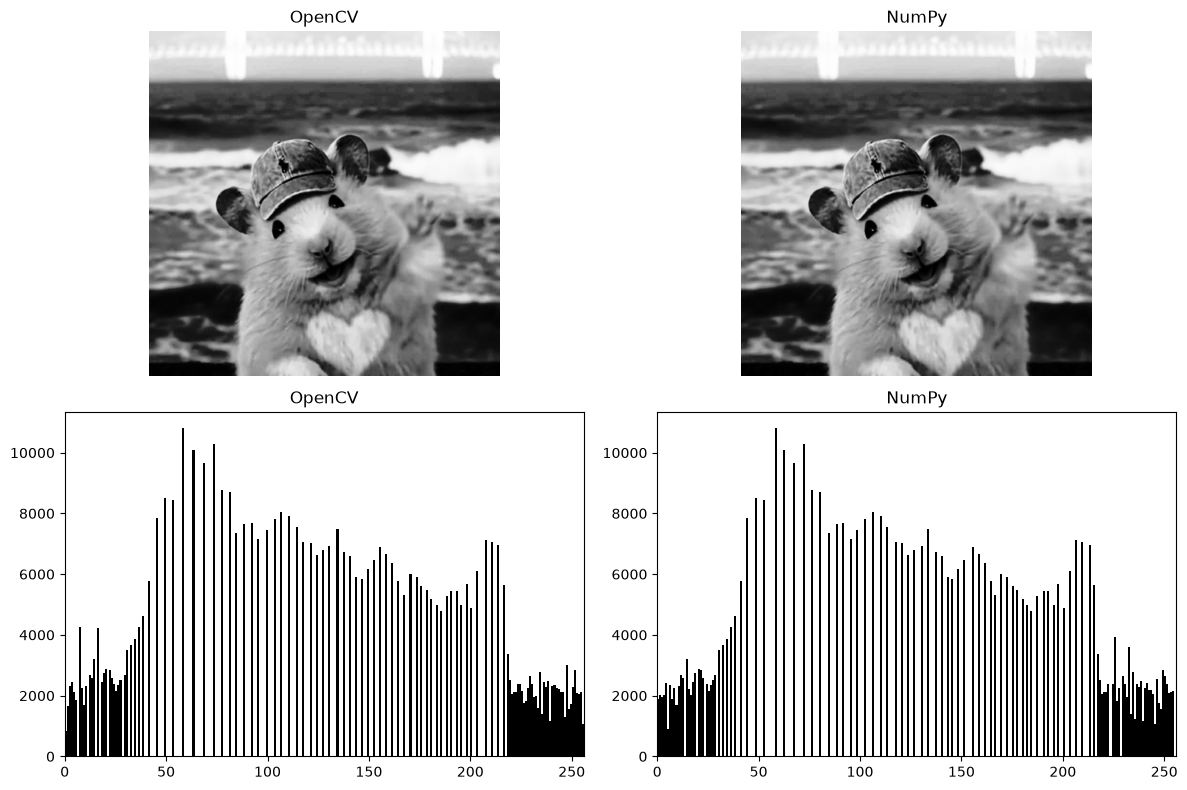

In [7]:
img = cv2.imread('Data/q2.jpg', cv2.IMREAD_GRAYSCALE)

equ_cv = cv2.equalizeHist(img)
equ_np = equalize_hist_numpy(img)

plot_image_and_hist_grid(equ_cv, equ_np, title_before="OpenCV", title_after="NumPy")

#### (3) 比較結果

In [8]:
# 計算差異矩陣 (轉成 int 避免 uint8 溢位)
diff_hist = np.abs(equ_cv.astype(int) - equ_np.astype(int))

max_diff = np.max(diff_hist)
mae = np.mean(diff_hist)

print(f"最大像素差值: {max_diff}")
print(f"平均絕對誤差 (MAE): {mae:.4f}")

最大像素差值: 1
平均絕對誤差 (MAE): 0.5457


## **Quiz3: 梯形校正與透視轉換**
**基礎** / 
- 選擇一張斜拍影像,利用 Perspective Transformation 將影像校正為正視影像

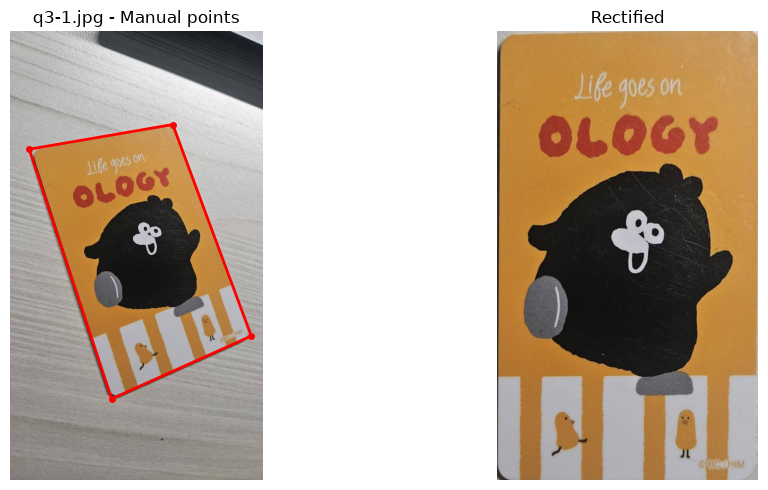

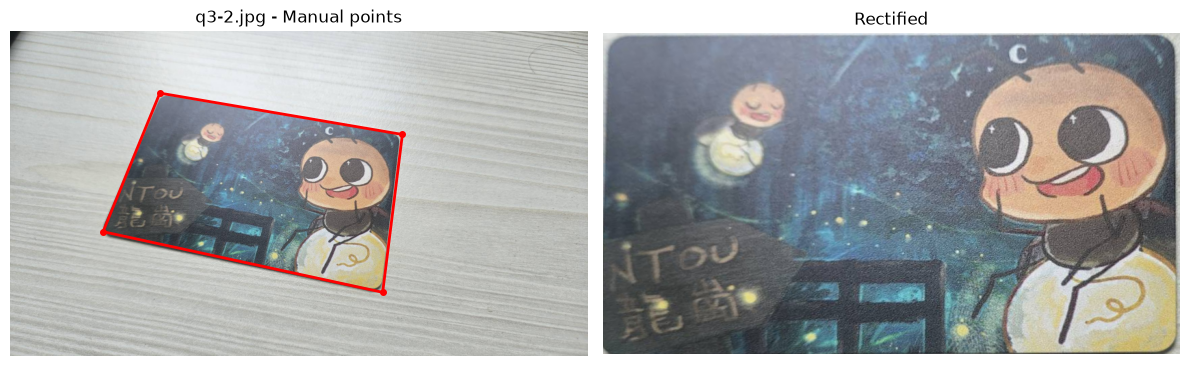

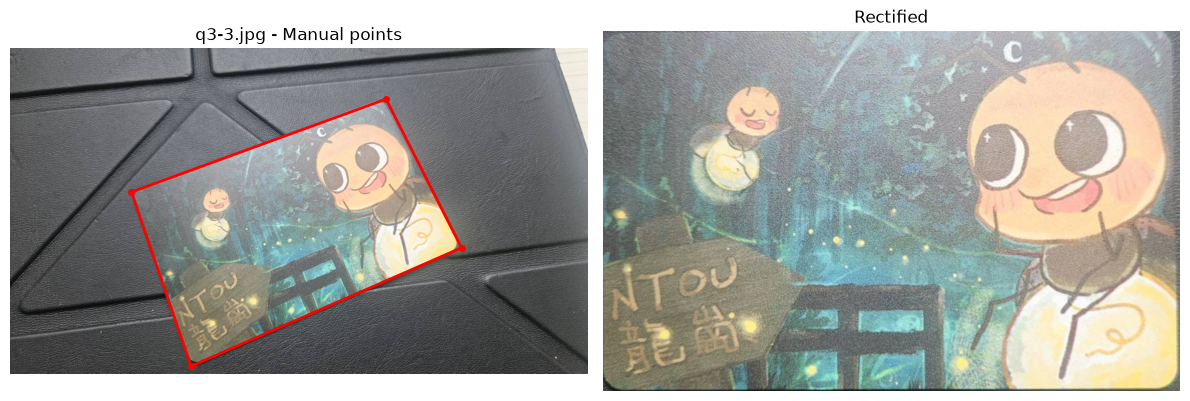

In [17]:
from pathlib import Path
import importlib

import cv2
import matplotlib.pyplot as plt

import Code.perspective as perspective

importlib.reload(perspective)
four_point_transform = perspective.four_point_transform
manual_select_points = perspective.manual_select_points

DATA_DIR = Path('Data')
OUT_DIR = DATA_DIR / 'output'
OUT_DIR.mkdir(parents=True, exist_ok=True)

image_paths = [DATA_DIR / 'q3-1.jpg', DATA_DIR / 'q3-2.jpg', DATA_DIR / 'q3-3.jpg']

for image_path in image_paths:
    image = cv2.imread(str(image_path))
    if image is None:
        print(f'讀取失敗: {image_path}')
        continue

    points = manual_select_points(
        image,
        title=f'{image_path.name}: 依序點選左上、右上、右下、左下'
    )
    warped, _ = four_point_transform(image, points)

    figure, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    axes[0].plot(points[:, 0], points[:, 1], 'r.-', linewidth=2, markersize=8)
    axes[0].plot([points[0, 0], points[-1, 0]],
                 [points[0, 1], points[-1, 1]], 'r-', linewidth=2)
    axes[0].set_title(f'{image_path.name} - Manual points')
    axes[0].axis('off')
    axes[1].imshow(cv2.cvtColor(warped, cv2.COLOR_BGR2RGB))
    axes[1].set_title('Rectified')
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()

#### **進階** /
- 將演算法應用於多張不同拍攝條件的影像，讓同一套流程可以針對多張影像自動完成梯形校正
(自動化程度越高，得分越高)
- 探討不同拍攝角度下的校正效果，找出演算法開始無法正確校正的角度或條件，並說明可能原因

q3-1.jpg: contour_4pt


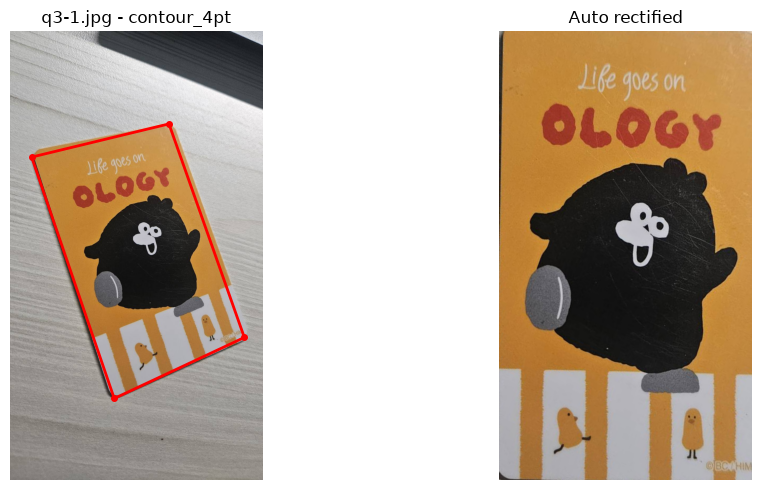

q3-2.jpg: contour_4pt


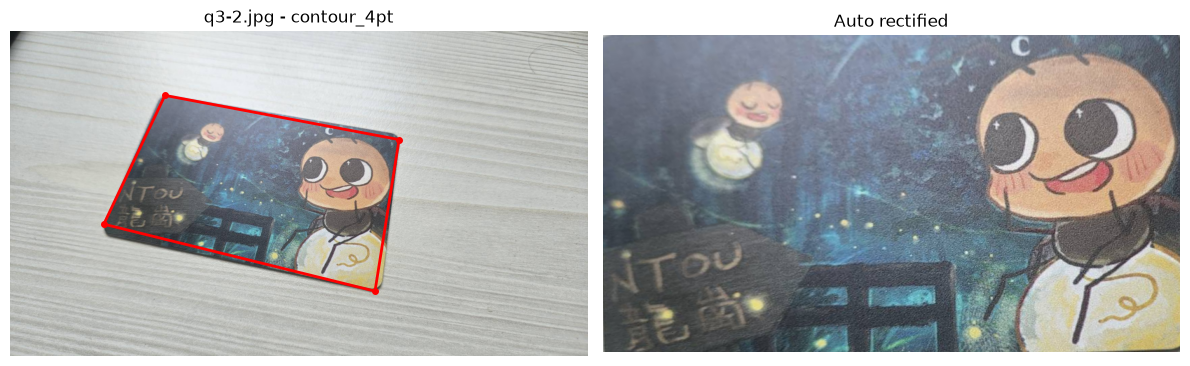

找不到四邊形: q3-3.jpg


In [15]:
import importlib

import cv2
import matplotlib.pyplot as plt

import Code.perspective as perspective

importlib.reload(perspective)
auto_detect_quad = perspective.auto_detect_quad
four_point_transform = perspective.four_point_transform

# 可以優先調整這三個參數
MIN_AREA_RATIO = 0.1
CANNY_LOW = 60
CANNY_HIGH = 150

for image_path in image_paths:
    image = cv2.imread(str(image_path))
    if image is None:
        print(f'讀取失敗: {image_path}')
        continue

    points, debug = auto_detect_quad(
        image,
        min_area_ratio=MIN_AREA_RATIO,
        canny_low=CANNY_LOW,
        canny_high=CANNY_HIGH,
        return_debug=True,
    )

    if points is None:
        print(f'找不到四邊形: {image_path.name}')
        continue

    warped, _ = four_point_transform(image, points)

    print(f'{image_path.name}: {debug["method"]}')
    figure, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    axes[0].plot(points[:, 0], points[:, 1], 'r.-', linewidth=2, markersize=8)
    axes[0].plot([points[0, 0], points[-1, 0]],
                 [points[0, 1], points[-1, 1]], 'r-', linewidth=2)
    axes[0].set_title(f'{image_path.name} - {debug["method"]}')
    axes[0].axis('off')
    axes[1].imshow(cv2.cvtColor(warped, cv2.COLOR_BGR2RGB))
    axes[1].set_title('Auto rectified')
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()

## **Quiz 4: 影像拼接**

#### **基礎** /
- 選擇兩張具有重疊區域的影像,使用 SIFT 等特徵偵測與匹配方法完成影像拼接

左圖特徵點: 2676
右圖特徵點: 858
有效匹配數: 139
RANSAC 內點數: 128
內點比例: 92.09%


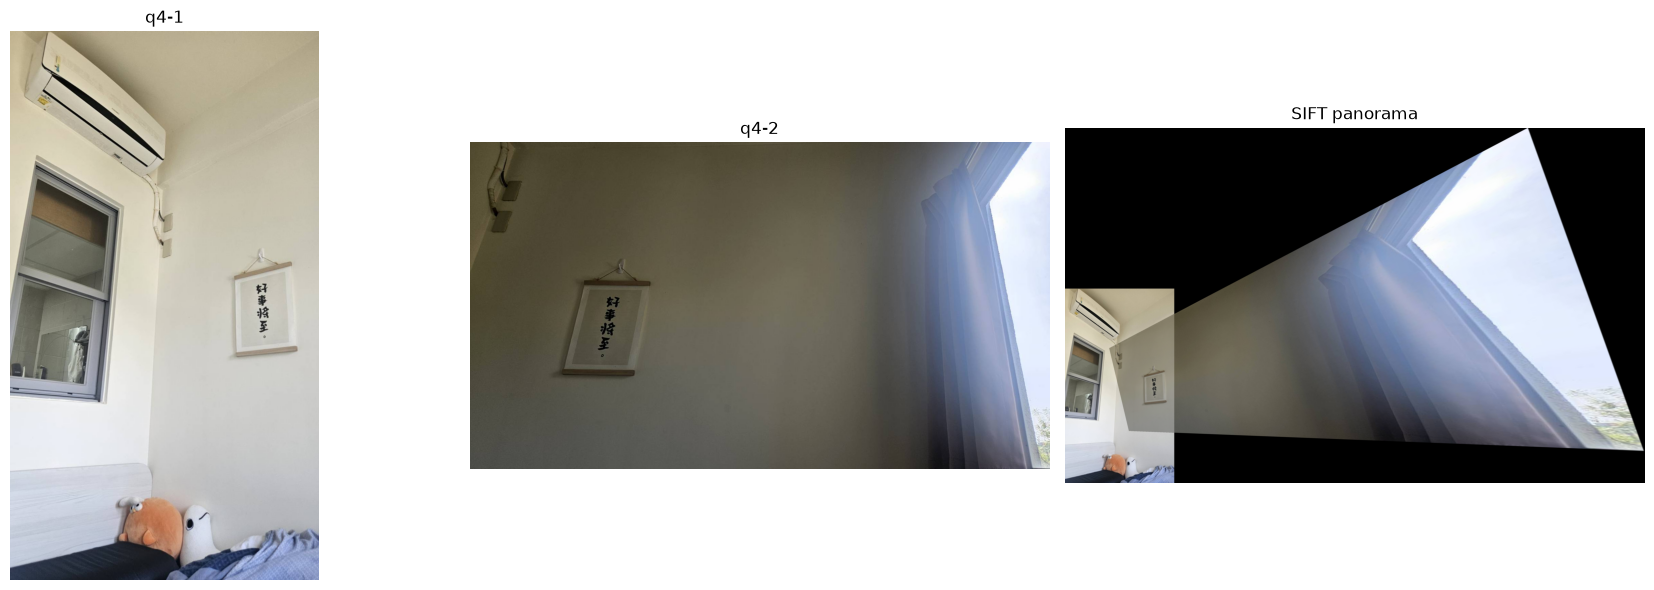

In [21]:
from pathlib import Path
import importlib

import cv2
import matplotlib.pyplot as plt

import Code.stitching as stitching

importlib.reload(stitching)

DATA_DIR = Path('Data')
OUT_DIR = DATA_DIR / 'output'
OUT_DIR.mkdir(parents=True, exist_ok=True)
left, right = stitching.load_quiz4_images(DATA_DIR)

stitched, info = stitching.stitch_images(left, right)
if stitched is None:
    raise RuntimeError(f'拼接失敗，匹配數量: {info["matches"]}')

cv2.imwrite(str(OUT_DIR / 'q4-stitched.jpg'), stitched)
print(f'左圖特徵點: {info["keypoints1"]}')
print(f'右圖特徵點: {info["keypoints2"]}')
print(f'有效匹配數: {info["matches"]}')
print(f'RANSAC 內點數: {info["inliers"]}')
print(f'內點比例: {info["inlier_ratio"]:.2%}')

figure, axes = plt.subplots(1, 3, figsize=(18, 6))
for axis, image, title in zip(
    axes,
    (left, right, stitched),
    ('q4-1', 'q4-2', 'SIFT panorama'),
):
    axis.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    axis.set_title(title)
    axis.axis('off')
plt.tight_layout()
plt.show()

#### **進階** /
- 調整影像的亮度、拍攝角度或重疊範圍，觀察在不同條件下的拼接效果，找出演算法開始無法成功拼接的條件，並說明可能原因
- 嘗試在影像拼接前加入適當的前處理方法，提升特徵偵測、匹配與拼接的穩定性


In [ ]:
import importlib

import cv2
import matplotlib.pyplot as plt

import Code.stitching as stitching

importlib.reload(stitching)
rows, results = stitching.run_experiments(left, right)

print('條件                     matches  inliers  inlier_ratio  result')
for row in rows:
    print(
        f'{row["name"]:<24} {row["matches"]:>7} {row["inliers"]:>8} '
        f'{row["inlier_ratio"]:>12.2%}  {"成功" if row["success"] else "失敗/不穩定"}'
    )

for name, image, _success in results:
    if name == 'CLAHE preprocessing':
        cv2.imwrite(str(OUT_DIR / 'q4-stitched-clahe.jpg'), image)

figure, axes = plt.subplots(2, 4, figsize=(18, 9))
for axis, (name, image, success) in zip(axes.ravel(), results):
    axis.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    axis.set_title(f'{name} - {"success" if success else "unstable"}')
    axis.axis('off')
for axis in axes.ravel()[len(results):]:
    axis.axis('off')
plt.tight_layout()
plt.show()

條件                     matches  inliers  inlier_ratio  result
baseline                     139      128       92.09%  成功
brighter +60                 141      128       90.78%  成功
darker -60                     5        0        0.00%  失敗/不穩定
rotated 8 degrees            163      146       89.57%  成功
rotated 20 degrees           143      125       87.41%  成功
reduced overlap              137      128       93.43%  成功
CLAHE preprocessing          138      117       84.78%  成功
